In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import optuna

from sm import NeuralNet
from tune_sm import find_control_voltages_1D

print(optuna.__version__)
optuna.logging.set_verbosity(optuna.logging.WARNING)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

def z_score(x):
    z = (x - x.mean()) / (x.std() + 1e-8) 
    return z

N = 100
c_volt_min = -1.5
c_volt_max = 1.5
in_volt_min = -1.5
in_volt_max = 1.5

x_full_range = np.linspace(-1.5, 1.5, N)
x_in_range = np.linspace(in_volt_min, in_volt_max, N)

state_dict = torch.load("/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_vMB_1e7.pth", weights_only=False, map_location=device)
print(state_dict["args"].keys())

model = NeuralNet(layer_dims=state_dict["args"]["layer_dims"])
model.load_state_dict(state_dict=state_dict["model_state_dict"])

model.eval()

4.4.0
cuda
dict_keys(['data_dir', 'num_batches', 'batch_size', 'normalize', 'layer_dims', 'num_epochs', 'lr', 'save_name'])


NeuralNet(
  (model): Sequential(
    (0): Linear(in_features=7, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True)
    (15): Linear(in_features=32, out_features=16, bias=True)
    (16

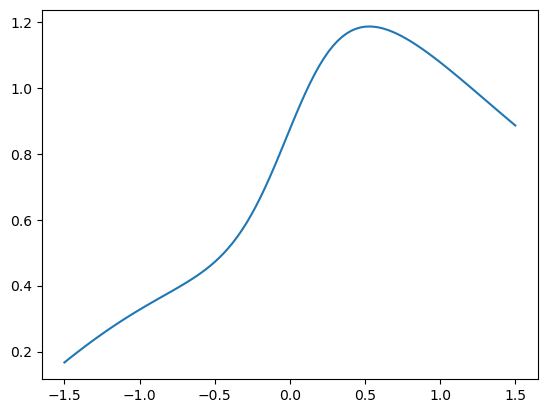

In [20]:
N = 100
def target_function(t: torch.Tensor):
    N = t.shape[0]
    m = nn.ELU()
    return -0.4*torch.cos(t+3.5) + torch.sigmoid(5*t)

target = target_function(torch.linspace(in_volt_min, in_volt_max, N)).unsqueeze(1)
plt.plot(np.linspace(in_volt_min, in_volt_max, N), target)

In [21]:
num_studies = 10
best_vals = []

study = find_control_voltages_1D(model=model, target=target, N=N, c_volt_min=c_volt_min, c_volt_max=c_volt_max, in_volt_min=in_volt_min, in_volt_max=in_volt_max, input_idx=0, n_startup_trials=500, n_trials=3000, PRINT_EVERY=1000)
  
print("Best value:", study.best_value)
print("Best params:", study.best_params)    

/home/hd/hd_hd/hd_gy283/.conda/envs/py311/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/home/hd/hd_hd/hd_gy283/.conda/envs/py311/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(


0] Finished with score:  0.090896
1000] Finished with score:  0.094545
2000] Finished with score:  0.184551
Best value: 0.00530015816912055
Best params: {'x_0': 0.48431840576432994, 'x_1': 1.4355513682559609, 'x_2': 0.26524962777854855, 'x_3': 1.2232097957855352, 'x_4': 0.31940916409508846, 'x_5': 0.08077324262584651}


[0.48431840576432994, 1.4355513682559609, 0.26524962777854855, 1.2232097957855352, 0.31940916409508846, 0.08077324262584651]


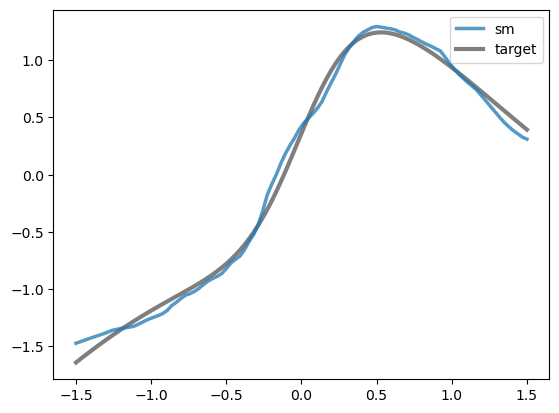

In [22]:
best_vals = []

for v in study.best_params.items():
    best_vals.append(v[1])
print(best_vals)

v = torch.linspace(-1.5, 1.5, N).unsqueeze(-1)
c_volts = torch.tensor(best_vals, dtype=torch.float32).expand(N, -1)

v_tensor = torch.cat([v, c_volts], dim=1)
with torch.no_grad():  
    y = model(v_tensor).cpu().detach()

target_mean = target.mean()
target_std = target.std()
target_norm = (target - target_mean) / target_std

y_norm = (y - y.mean()) / y.std()

sim_data = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/perturbation_experiment/vMB_sine_0.npz")
I_norm = z_score(sim_data["current"])
sem = sim_data["sem"] / sim_data["current"].std()

#plt.fill_between(x_in_range, I_norm-sem, I_norm+sem, label="sim", alpha=.5, zorder=4)
plt.plot(x_in_range, y_norm, label="sm", lw=2.5, alpha=.75, zorder=4)
plt.plot(x_in_range, target_norm, label="target", color="k", lw=3, alpha=.5, zorder=3)
plt.legend()

In [16]:
def refine_control_voltages(
    model, v, best_params, target, input_idx,
    steps=2_000, lr=1e-5, in_features=7
):
    device = next(model.parameters()).device
    model.eval()

    for p in model.parameters():
        p.requires_grad_(False)

    # build trainable controls starting from Optuna solution
    ctrl_cols = [c for c in range(in_features) if c != input_idx]
    c = torch.tensor(
        [best_params[f"x_{i}"] for i in range(in_features - 1)],
        dtype=torch.float32, device=device, requires_grad=True
    )
    opt = torch.optim.Adam([c], lr=lr)

    # z-score target once
    target = target.to(device).float()
    target_z = (target - target.mean()) / (target.std(unbiased=False) + 1e-8)

    v = v.to(device).float().view(-1)

    for _ in range(steps):
        X = torch.empty(v.shape[0], in_features, device=device, dtype=torch.float32)
        for col, val in zip(ctrl_cols, c):
            X[:, col] = val
        X[:, input_idx] = v

        y = model(X)
        y_z = (y - y.mean()) / (y.std(unbiased=False) + 1e-8)

        loss = torch.mean((y_z - target_z) ** 2)
        if _ % 1000 == 0:
            print(f"Loss: {loss.item()}")
        opt.zero_grad()
        loss.backward()
        opt.step()
        with torch.no_grad():
            c.clamp_(c_volt_min, c_volt_max)

    # return refined controls as a dict like Optuna's
    return {f"x_{i}": float(c.detach().cpu()[i]) for i in range(in_features - 1)}

best_c_dict = refine_control_voltages(model, v, study.best_params, target, 0)
c_opt = []
for k in best_c_dict.keys():
    c_opt.append(best_c_dict[k])
print(c_opt)

Loss: 0.005937374662607908
Loss: 0.005821700673550367
[0.4248979985713959, 1.4432117938995361, 1.446283221244812, -0.06424485146999359, -1.4469382762908936, 0.9943876266479492]


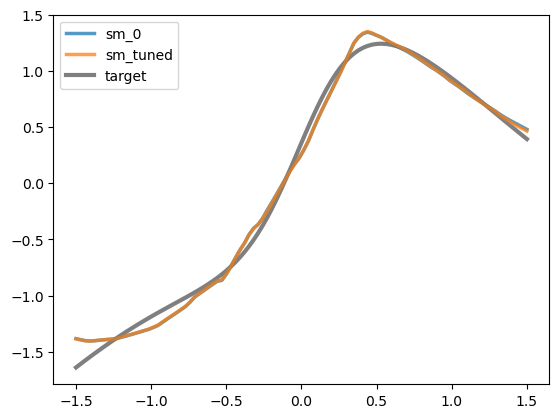

In [18]:
sim_data_0 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/perturbation_experiment/vMB_sine_0.npz")
I_norm_0 = z_score(sim_data_0["current"])
sem_0 = sim_data_0["sem"] / sim_data_0["current"].std()

sim_data_1 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/perturbation_experiment/vMB_sine_1.npz")
I_norm_1 = z_score(sim_data_1["current"])
sem_1 = sim_data_1["sem"] / sim_data_1["current"].std()

target = target_function(torch.linspace(-1.5, 1.5, 100))
target_norm = (target - target.mean()) / target.std()

tuned_c_volts = torch.tensor(c_opt, dtype=torch.float32).expand(N, -1)

tuned_input_tensor = torch.cat([torch.linspace(-1.5, 1.5, N).unsqueeze(1), tuned_c_volts], dim=1) 
tuned_y = model(tuned_input_tensor).detach().cpu()

tuned_y_norm = (tuned_y - tuned_y.mean()) / tuned_y.std()

#plt.fill_between(x_in_range, I_norm_0-sem_0, I_norm_0+sem_0, label="sim_0", alpha=.5, zorder=4)
#plt.fill_between(x_in_range, I_norm_1-sem_1, I_norm_1+sem_1, label="sim_1", alpha=.5, zorder=4)
plt.plot(x_in_range, y_norm, label="sm_0", lw=2.5, alpha=.75, zorder=4)
plt.plot(x_in_range, tuned_y_norm, label="sm_tuned", lw=2.5, alpha=.75, zorder=4)
plt.plot(x_in_range, target_norm, label="target", color="k", lw=3, alpha=.5, zorder=3)
plt.legend()